<a href="https://colab.research.google.com/github/rahulbedjavalge/rahuls/blob/main/20250531_Rahul_Bedjavalge_4243087_DLMDSPWP01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, Column, Integer, Float
from sqlalchemy.orm import declarative_base, sessionmaker
from sklearn.metrics import mean_squared_error
import unittest
import math

from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource
output_notebook()

# **Loading Datasets**

In [2]:
import zipfile
import os

with zipfile.ZipFile('/content/Datasets1.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/unzipped_datasets')

for filename in os.listdir('/content/unzipped_datasets'):
    filepath = os.path.join('/content/unzipped_datasets', filename)

    print(f"Filename: {filename}")

Filename: train.csv
Filename: test.csv
Filename: ideal.csv


In [3]:
ideal=pd.read_csv("/content/unzipped_datasets/ideal.csv")
ideal.head()

,x,y1,y2,y3,y4,y5,y6,y7,y8,y9,...,y41,y42,y43,y44,y45,y46,y47,y48,y49,y50
0,-20.0,-0.912945,0.408082,9.087055,5.408082,-9.087055,0.912945,-0.839071,-0.850919,0.816164,...,-40.456474,40.204040,2.995732,-0.008333,12.995732,5.298317,-5.298317,-0.186278,0.912945,0.396850
1,-19.9,-0.867644,0.497186,9.132356,5.497186,-9.132356,0.867644,-0.865213,0.168518,0.994372,...,-40.233820,40.048590,2.990720,-0.008340,12.990720,5.293305,-5.293305,-0.215690,0.867644,0.476954
2,-19.8,-0.813674,0.581322,9.186326,5.581322,-9.186326,0.813674,-0.889191,0.612391,1.162644,...,-40.006836,39.890660,2.985682,-0.008347,12.985682,5.288267,-5.288267,-0.236503,0.813674,0.549129
3,-19.7,-0.751573,0.659649,9.248426,5.659649,-9.248426,0.751573,-0.910947,-0.994669,1.319299,...,-39.775787,39.729824,2.980619,-0.008354,12.980619,5.283204,-5.283204,-0.247887,0.751573,0.612840
4,-19.6,-0.681964,0.731386,9.318036,5.731386,-9.318036,0.681964,-0.930426,0.774356,1.462772,...,-39.540980,39.565693,2.975530,-0.008361,12.975530,5.278115,-5.278115,-0.249389,0.681964,0.667902


In [4]:
test=pd.read_csv("/content/unzipped_datasets/test.csv")
test.head()

,x,y
0,17.5,34.161040
1,0.3,1.215102
2,-8.7,-16.843908
3,-19.2,-37.170870
4,-11.0,-20.263054


In [5]:
train=pd.read_csv("/content/unzipped_datasets/train.csv")
train.head()

,x,y1,y2,y3,y4
0,-20.0,39.778572,-40.078590,-20.214268,-0.324914
1,-19.9,39.604813,-39.784000,-20.070950,-0.058820
2,-19.8,40.099070,-40.018845,-19.906782,-0.451830
3,-19.7,40.151100,-39.518402,-19.389118,-0.612044
4,-19.6,39.795662,-39.360065,-19.815890,-0.306076


# **Data Exploration**

In [6]:
print("Missing values in Train:\n", train.isnull().sum())
print("Missing values in Ideal:\n", ideal.isnull().sum())
print("Missing values in Test:\n", test.isnull().sum())

display(train.describe())
display(ideal.describe())
display(test.describe())

Missing values in Train:
 x     0
y1    0
y2    0
y3    0
y4    0
dtype: int64
Missing values in Ideal:
 x      0
y1     0
y2     0
y3     0
y4     0
y5     0
y6     0
y7     0
y8     0
y9     0
y10    0
y11    0
y12    0
y13    0
y14    0
y15    0
y16    0
y17    0
y18    0
y19    0
y20    0
y21    0
y22    0
y23    0
y24    0
y25    0
y26    0
y27    0
y28    0
y29    0
y30    0
y31    0
y32    0
y33    0
y34    0
y35    0
y36    0
y37    0
y38    0
y39    0
y40    0
y41    0
y42    0
y43    0
y44    0
y45    0
y46    0
y47    0
y48    0
y49    0
y50    0
dtype: int64
Missing values in Test:
 x    0
y    0
dtype: int64


,x,y1,y2,y3,y4
count,400.00000,400.000000,400.000000,400.000000,400.000000
mean,-0.05000,0.107666,-0.094239,-0.051628,0.012633
std,11.56143,23.103285,23.111794,11.560369,0.327063
min,-20.00000,-39.724934,-40.078590,-20.214268,-0.744510
25%,-10.02500,-20.312566,-19.642560,-9.999807,-0.198240
50%,-0.05000,0.367844,-0.000603,-0.155205,0.024634
75%,9.92500,19.606209,19.478971,9.992209,0.236008
max,19.90000,40.151100,40.558865,19.840752,0.742489


,x,y1,y2,y3,y4,y5,y6,y7,y8,y9,...,y41,y42,y43,y44,y45,y46,y47,y48,y49,y50
count,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,...,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,-0.05000,-0.002282,0.045609,9.997718,5.045609,-9.997718,0.002282,-0.054391,0.030726,0.091218,...,-0.101141,0.122805,1.933863,-0.010131,11.933863,4.236448,-4.236448,-0.000466,0.029571,0.040336
std,11.56143,0.701386,0.713074,0.701386,0.713074,0.701386,0.701386,0.721907,0.717805,1.426147,...,23.109814,23.126395,1.814762,0.001190,1.814762,1.814762,1.814762,0.178079,0.700764,0.628002
min,-20.00000,-0.999990,-0.999968,9.000010,4.000032,-10.999990,-0.999990,-0.999965,-0.999998,-1.999937,...,-40.456474,-39.551407,-28.889038,-0.012484,-18.889038,-26.586452,-5.298317,-0.249998,-0.999990,-0.841454
25%,-10.02500,-0.695113,-0.669387,9.304887,4.330613,-10.689206,-0.689206,-0.801144,-0.672318,-1.338774,...,-19.767859,-20.288331,1.609438,-0.011102,11.609438,3.912023,-5.010635,-0.179723,-0.682927,-0.620496
50%,-0.05000,-0.003982,0.095868,9.996018,5.095868,-9.996018,0.003982,-0.095871,0.038803,0.191735,...,-0.124958,0.598751,2.302585,-0.009995,12.302585,4.605170,-4.605170,-0.001106,0.099833,0.095717
75%,9.92500,0.689206,0.753902,10.689206,5.753902,-9.304887,0.695113,0.672522,0.775285,1.507804,...,19.610421,19.637776,2.708050,-0.009089,12.708050,5.010635,-3.912023,0.178177,0.722881,0.684489
max,19.90000,0.999990,1.000000,10.999990,6.000000,-9.000010,0.999990,1.000000,0.999993,2.000000,...,40.233820,40.204040,2.995732,-0.008333,12.995732,5.298317,26.586452,0.249998,0.999574,0.841471


,x,y
count,100.000000,100.000000
mean,0.299000,0.325483
std,12.039501,20.745993
min,-20.000000,-40.449770
25%,-9.775000,-14.091911
50%,-0.500000,-0.038432
75%,11.700000,15.968556
max,19.700000,38.955273


NameError: name 'plt' is not defined

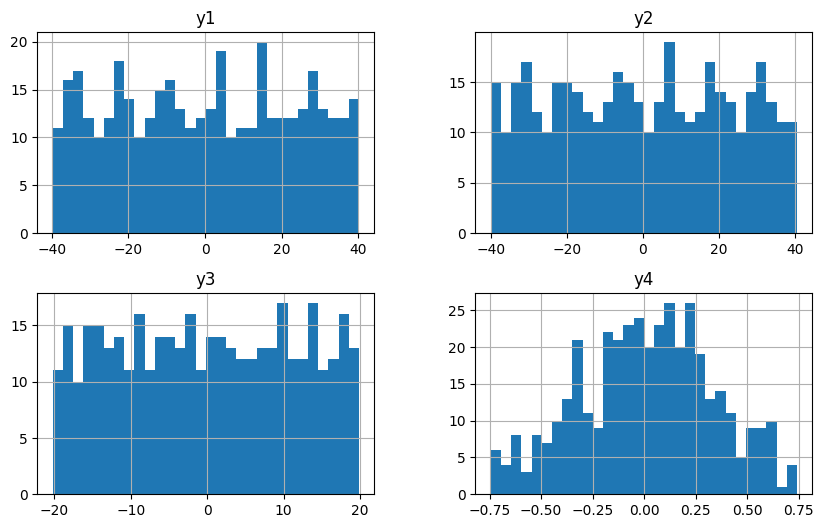

In [7]:
# Histogram of training function values
train[['y1', 'y2', 'y3', 'y4']].hist(bins=30, figsize=(10, 6))
plt.suptitle('Distribution of Training Y-values')
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(train[['y1', 'y2', 'y3', 'y4']].corr(), annot=True, cmap='coolwarm')
plt.title("Training Data Correlation")
plt.show()

# SQLAlchemy Setup

In [8]:
Base = declarative_base()

class TrainingData(Base):
    __tablename__ = 'training_data'
    id = Column(Integer, primary_key=True)
    x = Column(Float)
    y1 = Column(Float)
    y2 = Column(Float)
    y3 = Column(Float)
    y4 = Column(Float)

class IdealFunctions(Base):
    __tablename__ = 'ideal_functions'
    id = Column(Integer, primary_key=True)
    x = Column(Float)

class TestData(Base):
    __tablename__ = 'test_data'
    id = Column(Integer, primary_key=True)
    x = Column(Float)
    y = Column(Float)
    delta_y = Column(Float)
    ideal_function_id = Column(Integer)

# **Function Fitting Logic**

In [9]:
class FunctionFitting:
    def __init__(self, train_data, ideal_data):
        self.train_data = train_data
        self.ideal_data = ideal_data
        self.selected_functions = []

    def compute_deviation(self, y_train, y_ideal):
        return mean_squared_error(y_train, y_ideal)

    def select_ideal_functions(self):
        for i in range(4):
            deviations = []
            for j in range(1, 51):
                y_ideal = self.ideal_data[f'y{j}']
                deviation = self.compute_deviation(self.train_data[f'y{i+1}'], y_ideal)
                deviations.append((j, deviation))
            best_function = min(deviations, key=lambda x: x[1])
            self.selected_functions.append(best_function[0])

# **Test Data Mapping Logic**

In [10]:
class TestDataMapping:
    def __init__(self, test_data, ideal_data, selected_functions, train_data):
        self.test_data = test_data
        self.ideal_data = ideal_data
        self.selected_functions = selected_functions
        self.train_data = train_data
        self.mapped_data = []
        self.max_deviations = self.calculate_max_deviations()

    def calculate_max_deviations(self):
        max_devs = []
        for i in range(4):
            train_y = self.train_data[f'y{i+1}']
            ideal_y = self.ideal_data[f'y{self.selected_functions[i]}']
            deviation = abs(train_y - ideal_y)
            max_devs.append(deviation.max())
        return max_devs

    def compute_deviation(self, y_test, y_ideal):
        return abs(y_test - y_ideal)

    def map_test_data(self):
        for _, row in self.test_data.iterrows():
            x_test = row['x']
            y_test = row['y']
            mapped = False

            for i in range(4):
                ideal_row = self.ideal_data[self.ideal_data['x'] == x_test]
                if ideal_row.empty:
                    continue
                y_ideal = ideal_row[f'y{self.selected_functions[i]}'].values[0]
                delta_y = self.compute_deviation(y_test, y_ideal)
                if delta_y <= self.max_deviations[i] * math.sqrt(2):
                    self.mapped_data.append({
                        'x': x_test,
                        'y': y_test,
                        'delta_y': delta_y,
                        'ideal_function_id': self.selected_functions[i]
                    })
                    mapped = True
                    break
            if not mapped:
                continue